In [62]:
import warnings
warnings.filterwarnings("ignore")
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [63]:
# model = ChatGoogleGenerativeAI(
#     model="gemini-3.5-flash-lite"
# )

model = ChatOpenRouter(
    model="openrouter/free"
)

In [64]:
class LLMState(TypedDict):
    query:str
    response:str

In [65]:
def blog_outline(state:LLMState) -> LLMState:
    query = state["query"]

    prompt = f"Generate a short outline to create a blog on this topic : {query}\n note don't decorate response keep it in simple string or paragraph"

    response = model.invoke(prompt)

    state["query"] = "Topic: " + query + "\n" + "blog outline ->\n" + response.content

    return state

In [ ]:
def create_blog(state:LLMState) -> LLMState:

    query = state["query"]

    prompt = f"you are given a topic of blog , outline to instruct you to create blog now create a short blog -> \n{query}"

    response = model.invoke(prompt)

    state["response"] = response.content

    return state
    

In [67]:
graph = StateGraph(LLMState)

# Nodes
graph.add_node("blog_outline" , blog_outline)
graph.add_node("create_blog" , create_blog)

# Edges
graph.add_edge(START , "blog_outline")
graph.add_edge("blog_outline" , "create_blog")
graph.add_edge("create_blog" , END)

# compile
workflow = graph.compile()

In [68]:
initial_state = {
    "query" : "Artificial Intelligence",
    "response" : ""
}

final_state = workflow.invoke(initial_state)

In [69]:
print(final_state)

{'query': 'Topic: Artificial Intelligence\nblog outline ->\nThe blog post begins with an engaging introduction defining artificial intelligence and its rapid evolution in recent years. It then categorizes AI into types such as narrow and general intelligence, while explaining key concepts like machine learning and neural networks. A significant section covers practical applications across industries like healthcare, finance, and transportation to illustrate real-world utility. Following this, the outline addresses critical challenges including ethical concerns, algorithmic bias, and job displacement. Finally, the conclusion looks toward the future of AI, emphasizing the need for responsible development and summarizing the transformative potential of the technology.', 'response': '**Artificial Intelligence: From Curiosity to Everyday Reality**\n\n*By [Your Name]*  \n\n---\n\n### Introduction – What Is AI, and Why It Matters Now  \n\nArtificial intelligence (AI) once lived only in scienc

In [70]:
final_state["query"]

'Topic: Artificial Intelligence\nblog outline ->\nThe blog post begins with an engaging introduction defining artificial intelligence and its rapid evolution in recent years. It then categorizes AI into types such as narrow and general intelligence, while explaining key concepts like machine learning and neural networks. A significant section covers practical applications across industries like healthcare, finance, and transportation to illustrate real-world utility. Following this, the outline addresses critical challenges including ethical concerns, algorithmic bias, and job displacement. Finally, the conclusion looks toward the future of AI, emphasizing the need for responsible development and summarizing the transformative potential of the technology.'

In [71]:
final_state["response"]

'**Artificial Intelligence: From Curiosity to Everyday Reality**\n\n*By [Your Name]*  \n\n---\n\n### Introduction – What Is AI, and Why It Matters Now  \n\nArtificial intelligence (AI) once lived only in science‑fiction movies, but today it powers the apps we use, the cars we drive, and the diagnoses doctors make. In the past five years, advances in computing power, data availability, and algorithmic research have turned AI from a niche curiosity into a rapid‑evolving force reshaping virtually every sector. Understanding AI—what it is, how it works, and where it’s headed—has become essential for anyone who wants to navigate the modern world.\n\n---\n\n### Classifying AI: Narrow vs. General  \n\nAI isn’t a monolith; it’s usually divided into two broad categories:\n\n| Category | Description | Current Examples |\n|----------|-------------|-----------------|\n| **Narrow (or Weak) AI** | Systems designed to excel at a single task or a limited set of tasks. | Voice assistants (Siri, Alexa),

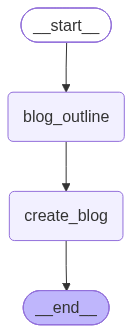

In [72]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())